# Fase 4 — Italia: OLS Cross-Sezionale

**The Airbnb Effect** · Digital Economy Group Project

---

## Domanda di ricerca

Nelle città italiane ad alta pressione turistica, la concentrazione di listing Airbnb è positivamente associata ai canoni di locazione residenziale, dopo aver controllato per la struttura urbana e le differenze strutturali tra città?

## Contesto e motivazione

Per le città italiane, il dataset non permette un'analisi ITS analoga a New York: le quotazioni OMI sono disponibili solo su base **semestrale** (5 periodi tra 2023 e 2025), troppo pochi per identificare un effetto causale in time series. Non esiste nemmeno un evento regolatorio comparabile a LL18.

La strategia alternativa sfrutta la **variazione cross-sezionale**: confrontiamo le zone OMI all'interno delle città e le città tra loro. Le zone a maggiore pressione Airbnb dovrebbero mostrare canoni più elevati, *ceteris paribus*.

## Ipotesi

- **H₁ (principale)**: La densità Airbnb è positivamente associata ai canoni → *β > 0*
- **H₂ (cross-city)**: L'effetto è più forte a Firenze, dove la saturazione Airbnb in rapporto alla popolazione è massima
- **H₀ (nulla)**: β = 0, nessuna associazione significativa

## Il modello

$$\text{loc\_medio}_{z,t} = \alpha + \beta \, \log(1 + \text{density}_{c,t}) + \gamma_f + \delta_c + \varepsilon_{z,t}$$

| Simbolo | Descrizione |
|---------|-------------|
| $\text{loc\_medio}_{z,t}$ | **Target**: canone OMI medio in €/m²/mese per zona $z$ al semestre $t$ |
| $\log(1 + \text{density}_{c,t})$ | **Regressore chiave**: log del numero medio di listing Airbnb attivi per città $c$ al semestre $t$ |
| $\gamma_f$ | **Fascia FE**: assorbe le differenze strutturali tra centro (B), semicentro (C), periferia (D/E) |
| $\delta_c$ | **City FE**: assorbe il diverso livello assoluto dei canoni tra Roma, Milano e Firenze |
| $\beta$ | **Parametro chiave**: associazione tra pressione Airbnb e canoni residenziali |

### Nota sull'identificazione

La densità Airbnb varia nel panel a livello **città × semestre** (non a livello di singola zona, che richiederebbe un spatial join GIS tra confini neighbourhood Airbnb e zone catastali OMI). Il coefficiente β è quindi identificato dalla variazione *tra città* e *nel tempo* — una variazione limitata ma reale e osservabile. Le fascia FE assorbono le differenze tra centro e periferia, i city FE le differenze di scala tra mercati.

> **N ≈ 6.800 osservazioni zona × semestre** con 15 valori distinti del regressore (3 città × 5 semestri).
> Gli errori standard sono **clusterizzati a livello città × semestre** per correggere la correlazione intra-cluster.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.api as sm
import glob, os, re, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

CITIES_IT = ['Roma', 'Milano', 'Firenze']
COLORS = {'Roma': '#e74c3c', 'Milano': '#3498db', 'Firenze': '#2ecc71'}
os.makedirs('plots', exist_ok=True)

print('Librerie caricate.')

Librerie caricate.


---

## 1. Caricamento dati OMI — panel a livello di zona

I file OMI contengono due dataset per ogni città × semestre:
- **VALORI** (`CITTÀ_VALORI_ANNO_S.csv`): quotazioni €/m² per zona e tipologia. Filtro su `Cod_Tip = 20` (abitazioni civili).
- **ZONE** (`CITTÀ_ZONE_ANNO_S.csv`): metadati delle zone catastali, inclusa la **Fascia** (B=centro storico / semicentro, C=periferia urbana, D=suburbana, E=extraurbana, R=rurale).

Il join tra i due dataset avviene sulla chiave comune `LinkZona`.

In [2]:
SEM_DATE = {
    '2023_1': '2023-06-30',
    '2023_2': '2023-12-31',
    '2024_1': '2024-06-30',
    '2024_2': '2024-12-31',
    '2025_1': '2025-06-30',
}
SEM_ORDER = {'2023_1': 0, '2023_2': 1, '2024_1': 2, '2024_2': 3, '2025_1': 4}

def load_omi_zona(city_name, omi_dir='data/omi'):
    """Carica VALORI + ZONE OMI e restituisce un DataFrame zona-semestre con Fascia."""
    city_upper = city_name.upper()
    city_dir = os.path.join(omi_dir, city_name)

    dfs_v, dfs_z = [], []
    for f in sorted(glob.glob(os.path.join(city_dir, f'{city_upper}_VALORI_*.csv'))):
        m = re.search(r'(\d{4}_\d)', os.path.basename(f))
        sem = m.group(1) if m else 'unknown'
        df = pd.read_csv(f, sep=';', skiprows=1)
        df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], inplace=True, errors='ignore')
        df['semestre'] = sem
        dfs_v.append(df)

    for f in sorted(glob.glob(os.path.join(city_dir, f'{city_upper}_ZONE_*.csv'))):
        m = re.search(r'(\d{4}_\d)', os.path.basename(f))
        sem = m.group(1) if m else 'unknown'
        df = pd.read_csv(f, sep=';', skiprows=1)
        df.drop(columns=[c for c in df.columns if c.startswith('Unnamed')], inplace=True, errors='ignore')
        df['semestre'] = sem
        dfs_z.append(df)

    valori = pd.concat(dfs_v, ignore_index=True) if dfs_v else pd.DataFrame()
    zone   = pd.concat(dfs_z, ignore_index=True) if dfs_z else pd.DataFrame()
    return valori, zone

# ── Caricamento per le tre città ──────────────────────────────────────────────
all_v, all_z = [], []
for city in CITIES_IT:
    v, z = load_omi_zona(city)
    v['city'] = city
    z['city'] = city
    all_v.append(v)
    all_z.append(z)

df_valori = pd.concat(all_v, ignore_index=True)
df_zone   = pd.concat(all_z, ignore_index=True)

# Verifica colonne ZONE
print('Colonne VALORI:', [c for c in df_valori.columns if c not in ['city','semestre']][:8], '...')
print('Colonne ZONE:  ', [c for c in df_zone.columns   if c not in ['city','semestre']])
print(f'\nTotale VALORI: {len(df_valori)} righe')
print(f'Totale ZONE:   {len(df_zone)} righe')

Colonne VALORI: ['Area_territoriale', 'Regione', 'Prov', 'Comune_ISTAT', 'Comune_cat', 'Sez', 'Comune_amm', 'Comune_descrizione'] ...
Colonne ZONE:   ['Area_territoriale', 'Regione', 'Prov', 'Comune_ISTAT', 'Comune_cat', 'Sez', 'Comune_amm', 'Comune_descrizione', 'Fascia', 'Zona_Descr', 'Zona', 'LinkZona', 'Cod_tip_prev', 'Descr_tip_prev', 'Stato_prev', 'Microzona']

Totale VALORI: 37682 righe
Totale ZONE:   6953 righe


In [3]:
# ── Filtro Cod_Tip=20 (abitazioni civili) e calcolo loc_medio ─────────────────
df_ab = df_valori[df_valori['Cod_Tip'] == 20].copy()

for col in ['Loc_min', 'Loc_max']:
    df_ab[col] = pd.to_numeric(
        df_ab[col].astype(str).str.replace(',', '.'), errors='coerce'
    )

df_ab['loc_medio'] = (df_ab['Loc_min'] + df_ab['Loc_max']) / 2
df_ab = df_ab.dropna(subset=['loc_medio'])

print(f'Zona-semestre con loc_medio valido: {len(df_ab)}')
print(f'Zone uniche: {df_ab["LinkZona"].nunique()}')
print()
print('Distribuzione per città e semestre:')
print(df_ab.groupby(['city','semestre']).size().unstack('semestre').to_string())

Zona-semestre con loc_medio valido: 6858
Zone uniche: 1063

Distribuzione per città e semestre:
semestre  2023_1  2023_2  2024_1  2024_2  2025_1
city                                            
Firenze      185     185     185     179     179
Milano       717     717     717     710     710
Roma         474     474     474     476     476


In [4]:
# ── Join VALORI + ZONE per ottenere Fascia per ogni zona ─────────────────────
# La colonna fascia nei file ZONE si chiama 'Fascia' (maiuscolo iniziale)
# Valori: B=centro/semicentro, C=periferia urbana, D=suburbana, E=extraurbana, R=rurale

zone_slim = (
    df_zone[['LinkZona', 'semestre', 'city', 'Fascia', 'Zona_Descr']]
    .drop_duplicates(['LinkZona', 'semestre', 'city'])
    .rename(columns={'Fascia': 'fascia', 'Zona_Descr': 'zona_descr'})
)

df_zona_panel = df_ab.merge(zone_slim, on=['LinkZona', 'semestre', 'city'], how='left')

print('Distribuzione fasce nel panel zona-semestre:')
print(df_zona_panel.groupby(['city', 'fascia']).size().unstack('fascia').fillna(0).astype(int).to_string())

print(f'\nN totale osservazioni zona×semestre: {len(df_zona_panel)}')
print(f'Valori fascia: {sorted(df_zona_panel["fascia"].dropna().unique())}')
print('  B=centro/semicentro  C=periferia urbana  D=suburbana  E=extraurbana  R=rurale')

Distribuzione fasce nel panel zona-semestre:
fascia      B    C     D    E    R
city                              
Firenze   253   70   145  195  250
Milano   2010  161  1032  338   30
Roma      670  230   568  891   15

N totale osservazioni zona×semestre: 6858
Valori fascia: ['B', 'C', 'D', 'E', 'R']
  B=centro/semicentro  C=periferia urbana  D=suburbana  E=extraurbana  R=rurale


---

## 2. Dati Airbnb — listing attivi per città e semestre

Dal panel già costruito in Fase 1 (`panel_italy.csv`) estraiamo il numero di listing *Entire home/apt* attivi per ogni città × semestre. Il semestre viene assegnato in base alla data mensile:

In [5]:
# ── Carica panel mensile italiano ─────────────────────────────────────────────
panel_it = pd.read_csv('data/processed/panel_italy.csv', parse_dates=['date'])

# Assegna il semestre a ogni osservazione mensile
def date_to_semestre(date):
    return f'{date.year}_{"1" if date.month <= 6 else "2"}'

panel_it['semestre'] = panel_it['date'].apply(date_to_semestre)

# Media listing per città × semestre (in caso di più mesi nello stesso semestre)
airbnb_sem = (
    panel_it
    .groupby(['city', 'semestre'])
    .agg(n_listings=('n_listings', 'mean'))
    .reset_index()
)

print('Listing medi per città × semestre (Entire home/apt):')
print(airbnb_sem.pivot(index='city', columns='semestre', values='n_listings').round(0).to_string())

print(f'\nN combinazioni città×semestre disponibili: {len(airbnb_sem)}')

Listing medi per città × semestre (Entire home/apt):
semestre   2024_1   2024_2   2025_1
city                               
Firenze    8173.0   8782.0  10047.0
Milano    15762.0  16655.0  17216.0
Roma      19164.0  20276.0  23074.0

N combinazioni città×semestre disponibili: 9


---

## 3. Costruzione del panel OLS

Unit di osservazione: **zona OMI × semestre**.

Ogni zona riceve la densità Airbnb della propria città nel semestre corrispondente. Questo implica che la variazione nel regressore chiave è **between-city e across-time**, non intra-zona. I fascia FE catturano le differenze strutturali tra zone; i city FE catturano i livelli assoluti diversi tra mercati.

In [6]:
# ── Join zona panel + Airbnb density ─────────────────────────────────────────
panel_ols = df_zona_panel.merge(
    airbnb_sem[['city', 'semestre', 'n_listings']],
    on=['city', 'semestre'],
    how='inner'
)

# Variabili per il modello
panel_ols['log1p_listings'] = np.log1p(panel_ols['n_listings'])
panel_ols['t'] = panel_ols['semestre'].map(SEM_ORDER).fillna(0).astype(int)

# Rimuove fascia rurale (R) — troppo poche osservazioni e contesto diverso
panel_ols = panel_ols[panel_ols['fascia'].isin(['B','C','D','E'])].dropna(subset=['loc_medio','fascia'])

print(f'Panel OLS finale: {len(panel_ols)} osservazioni zona×semestre')
print(f'Zone uniche:      {panel_ols["LinkZona"].nunique()}')
print(f'Fascia:           {sorted(panel_ols["fascia"].unique())}')
print(f'Range loc_medio:  {panel_ols["loc_medio"].min():.2f} – {panel_ols["loc_medio"].max():.2f} €/m²/mese')
print()
print('Distribuzione per città e fascia:')
print(panel_ols.groupby(['city','fascia']).size().unstack('fascia').fillna(0).astype(int).to_string())

Panel OLS finale: 3929 osservazioni zona×semestre
Zone uniche:      1002
Fascia:           ['B', 'C', 'D', 'E']
Range loc_medio:  2.00 – 42.55 €/m²/mese

Distribuzione per città e fascia:
fascia      B    C    D    E
city                        
Firenze   147   42   87  117
Milano   1206   95  612  206
Roma      402  138  340  537


---

## 4. Analisi esplorativa del panel

In [7]:
print('=== Statistiche descrittive — Panel OLS ===')
print()
print('loc_medio (€/m²/mese) per città e fascia:')
print(panel_ols.groupby(['city','fascia'])['loc_medio'].mean().round(2).unstack('fascia').to_string())
print()
print('n_listings (Entire home/apt) per città × semestre:')
print(panel_ols.groupby(['city','semestre'])['n_listings'].first().unstack('semestre').round(0).to_string())
print()
print('log(1+n_listings) per città:')
print(panel_ols.groupby('city')['log1p_listings'].mean().round(3).to_string())

=== Statistiche descrittive — Panel OLS ===

loc_medio (€/m²/mese) per città e fascia:
fascia      B     C     D     E
city                           
Firenze  5.99  10.1  7.72  5.69
Milano   8.41  15.6  9.06  6.83
Roma     6.10  13.3  8.94  7.84

n_listings (Entire home/apt) per città × semestre:
semestre   2024_1   2024_2   2025_1
city                               
Firenze    8173.0   8782.0  10047.0
Milano    15762.0  16655.0  17216.0
Roma      19164.0  20276.0  23074.0

log(1+n_listings) per città:
city
Firenze    9.100
Milano     9.713
Roma       9.942


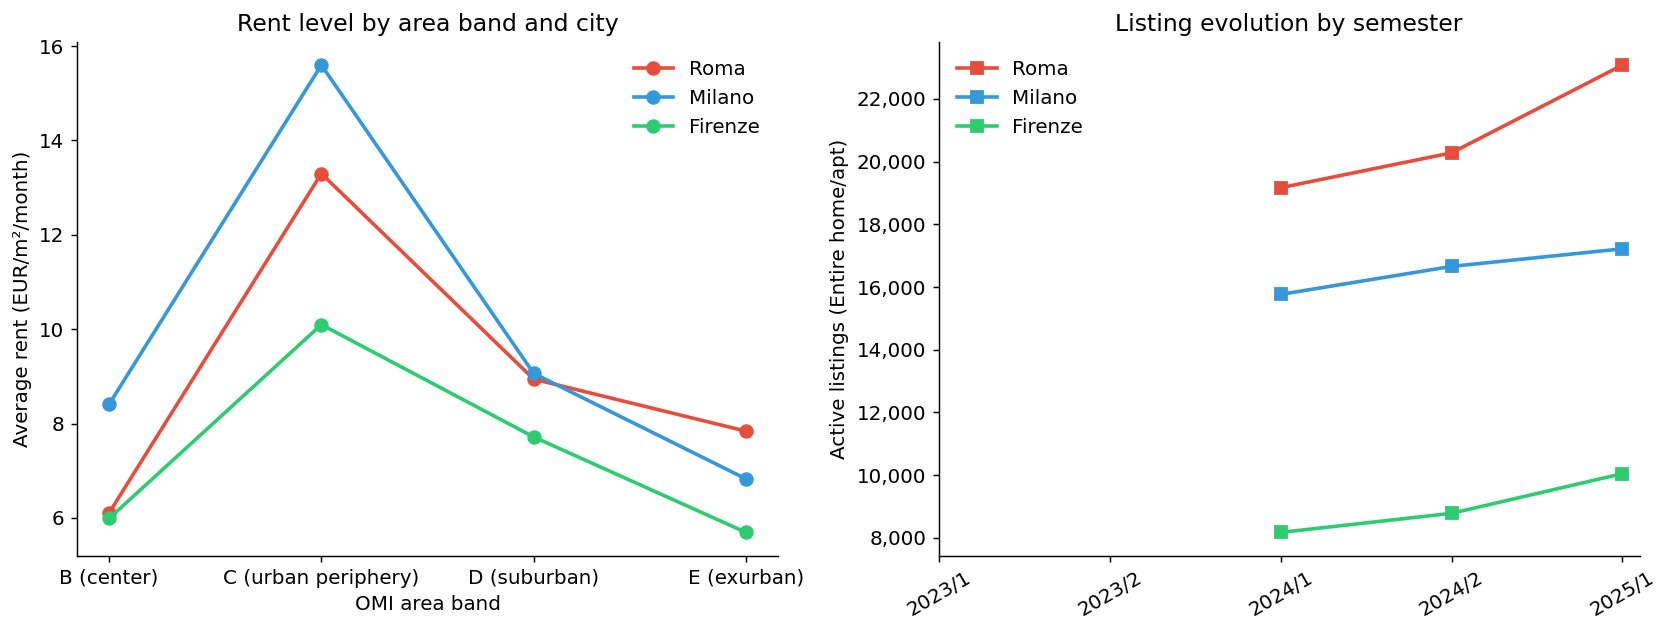

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: average rent by area band and city
ax = axes[0]
fasce_order = ['B','C','D','E']
fascia_labels = {'B':'B (center)', 'C':'C (urban periphery)', 'D':'D (suburban)', 'E':'E (exurban)'}

for city in CITIES_IT:
    sub = panel_ols[panel_ols['city']==city]
    means = sub.groupby('fascia')['loc_medio'].mean().reindex(fasce_order)
    ax.plot([fascia_labels.get(f, f) for f in means.dropna().index],
            means.dropna().values, marker='o', linewidth=2,
            color=COLORS[city], label=city, markersize=7)

ax.set_ylabel('Average rent (EUR/m²/month)')
ax.set_xlabel('OMI area band')
ax.set_title('Rent level by area band and city')
ax.legend(frameon=False)

# Plot 2: listing trend by city
ax2 = axes[1]
sem_labels = ['2023/1','2023/2','2024/1','2024/2','2025/1']

for city in CITIES_IT:
    sub = panel_ols[panel_ols['city']==city].drop_duplicates('semestre').sort_values('t')
    ax2.plot(sub['t'], sub['n_listings'], marker='s', linewidth=2,
             color=COLORS[city], label=city, markersize=7)

ax2.set_xticks(range(5))
ax2.set_xticklabels(sem_labels, rotation=30)
ax2.set_ylabel('Active listings (Entire home/apt)')
ax2.set_title('Listing evolution by semester')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax2.legend(frameon=False)

plt.tight_layout()
plt.savefig('plots/ols_01_exploratory.png', bbox_inches='tight')
plt.show()

---

## 5. Stima del modello OLS

Tre specificazioni progressive. Il modello con trend temporale è **escluso dall'analisi principale**: il trend dei listing e l'indice semestrale sono troppo correlati per essere identificati separatamente con soli 5 semestri — il β inverte segno e diventa non significativo, segnalando un problema di collinearità e non un effetto reale.

`fascia_E` (extraurbana) risulta non significativa nel modello completo (p = 0.455): le zone extraurbane non sono statisticamente diverse dal centro/semicentro (fascia_B, categoria di riferimento). Le dummies di fascia includono quindi solo **C** e **D**.

| Modello | Regressori |
|---------|------------|
| (1) Base | `log1p_listings` |
| (2) City FE | `log1p_listings` + dummy Roma + dummy Firenze |
| **(3) City + Fascia FE** *(principale)* | (2) + dummy C + dummy D |

In [9]:
# ── Preparazione matrici X ────────────────────────────────────────────────────
y = panel_ols['loc_medio'].values.astype(float)

# Dummies città: .astype(int) necessario con pandas 2.x
city_d  = pd.get_dummies(panel_ols['city'], prefix='city', drop_first=True).astype(int)

# Fascia FE: solo C e D — fascia_E non significativa (p=0.455, ns), trattata come B (riferimento)
fascia_d = (
    pd.get_dummies(panel_ols['fascia'], prefix='fascia')
    .drop(columns=['fascia_B', 'fascia_E'], errors='ignore')
    .astype(int)
)

logs = panel_ols[['log1p_listings']].values.astype(float)

X1 = sm.add_constant(logs)
X2 = sm.add_constant(np.column_stack([logs, city_d.values]))
X3 = sm.add_constant(np.column_stack([logs, city_d.values, fascia_d.values]))

X1_df = pd.DataFrame(X1, columns=['const', 'log1p_listings'])
X2_df = pd.DataFrame(X2, columns=['const', 'log1p_listings'] + list(city_d.columns))
X3_df = pd.DataFrame(X3, columns=['const', 'log1p_listings'] + list(city_d.columns) + list(fascia_d.columns))

results = {}
results['(1) Base']           = sm.OLS(y, X1_df).fit(cov_type='HC3')
results['(2) City FE']        = sm.OLS(y, X2_df).fit(cov_type='HC3')
results['(3) City+Fascia FE'] = sm.OLS(y, X3_df).fit(cov_type='HC3')

print("Modelli stimati con errori standard HC3 (robusti all'eteroschedasticità).")
print()
print(results['(3) City+Fascia FE'].summary())

Modelli stimati con errori standard HC3 (robusti all'eteroschedasticità).

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.174
Model:                            OLS   Adj. R-squared:                  0.173
Method:                 Least Squares   F-statistic:                     136.3
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          1.23e-133
Time:                        14:35:05   Log-Likelihood:                -10790.
No. Observations:                3929   AIC:                         2.159e+04
Df Residuals:                    3923   BIC:                         2.163e+04
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [10]:
# ── Tabella comparativa ───────────────────────────────────────────────────────
print('=== Tabella comparativa dei modelli OLS — variabile chiave: log(1 + listing) ===')
print()
header = f'{"Modello":<24} {"β":>8} {"SE(HC3)":>8} {"p-val":>8} {"sig":>4} {"R²":>7} {"R²-adj":>8} {"N":>6}'
print(header)
print('─' * len(header))

for name, m in results.items():
    b  = m.params['log1p_listings']
    se = m.bse['log1p_listings']
    pv = m.pvalues['log1p_listings']
    sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.1 else 'ns'
    print(f'{name:<24} {b:>8.4f} {se:>8.4f} {pv:>8.4f} {sig:>4} {m.rsquared:>7.4f} {m.rsquared_adj:>8.4f} {int(m.nobs):>6}')

print()
print('Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo')
print("SE stimati con sandwich HC3 (robusti all'eteroschedasticità)")
print()
print('Nota: fascia_E esclusa dalle dummies (non significativa; trattata come fascia_B).')
print()
print('Interpretazione β:')
print('  β > 0 → densità Airbnb positivamente associata ai canoni (supporta H₁)')
print('  Un raddoppio dei listing → Δ canone ≈ β × ln(2) ≈ β × 0.693 €/m²/mese')

=== Tabella comparativa dei modelli OLS — variabile chiave: log(1 + listing) ===

Modello                         β  SE(HC3)    p-val  sig      R²   R²-adj      N
────────────────────────────────────────────────────────────────────────────────
(1) Base                   1.5902   0.1942   0.0000  ***  0.0088   0.0085   3929
(2) City FE                3.2304   0.9976   0.0012  ***  0.0239   0.0232   3929
(3) City+Fascia FE         3.2764   0.8920   0.0002  ***  0.1741   0.1731   3929

Legenda: *** p<0.01  ** p<0.05  * p<0.10  ns non significativo
SE stimati con sandwich HC3 (robusti all'eteroschedasticità)

Nota: fascia_E esclusa dalle dummies (non significativa; trattata come fascia_B).

Interpretazione β:
  β > 0 → densità Airbnb positivamente associata ai canoni (supporta H₁)
  Un raddoppio dei listing → Δ canone ≈ β × ln(2) ≈ β × 0.693 €/m²/mese


---

## 6. OLS per città separata — verifica H₂

L'ipotesi H₂ predice che il coefficiente β sia più elevato a **Firenze**, dove il rapporto listing/residente è il più alto tra le tre città. Firenze ha ~10.000 listing attivi su ~350.000 residenti (≈ 1 listing ogni 35 abitanti), contro circa 1/100 per Milano e Roma.

In [11]:
city_results = {}
print('=== OLS per città (modello con Fascia FE) ===')
print()

for city in CITIES_IT:
    sub = panel_ols[panel_ols['city'] == city].copy()
    y_c = sub['loc_medio'].values.astype(float)
    logs_c = sub[['log1p_listings']].values.astype(float)

    if sub['fascia'].nunique() > 1:
        f_d = pd.get_dummies(sub['fascia'], prefix='fascia', drop_first=True).astype(int)
        X_c = sm.add_constant(np.column_stack([logs_c, f_d.values]))
        X_c_df = pd.DataFrame(X_c, columns=['const', 'log1p_listings'] + list(f_d.columns))
        spec = 'Fascia FE'
    else:
        X_c_df = pd.DataFrame(sm.add_constant(logs_c), columns=['const', 'log1p_listings'])
        spec = 'OLS base'

    m_c = sm.OLS(y_c, X_c_df).fit(cov_type='HC3')
    city_results[city] = m_c

    b  = m_c.params['log1p_listings']
    se = m_c.bse['log1p_listings']
    pv = m_c.pvalues['log1p_listings']
    sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.1 else 'ns'
    ci_lo, ci_hi = m_c.conf_int().loc['log1p_listings']
    print(f'{city:<10} ({spec})')
    print(f'  N={int(m_c.nobs):<4}  β={b:+.4f}  SE={se:.4f}  p={pv:.4f} {sig}  IC95=[{ci_lo:.4f}, {ci_hi:.4f}]  R²={m_c.rsquared:.4f}')
    print()

betas = {c: city_results[c].params['log1p_listings'] for c in CITIES_IT}
print('=== Ranking β per città (verifica H₂) ===')
for city, b in sorted(betas.items(), key=lambda x: x[1], reverse=True):
    print(f'  {city:<10}: β = {b:+.4f}')

=== OLS per città (modello con Fascia FE) ===

Roma       (Fascia FE)
  N=1417  β=+1.9885  SE=1.1366  p=0.0802 *  IC95=[-0.2392, 4.2161]  R²=0.2690

Milano     (Fascia FE)
  N=2119  β=+9.7634  SE=2.4969  p=0.0001 ***  IC95=[4.8696, 14.6571]  R²=0.1320

Firenze    (Fascia FE)
  N=393   β=+0.8485  SE=1.1412  p=0.4572 ns  IC95=[-1.3882, 3.0853]  R²=0.3582

=== Ranking β per città (verifica H₂) ===
  Milano    : β = +9.7634
  Roma      : β = +1.9885
  Firenze   : β = +0.8485


---

## 7. Visualizzazione dei risultati

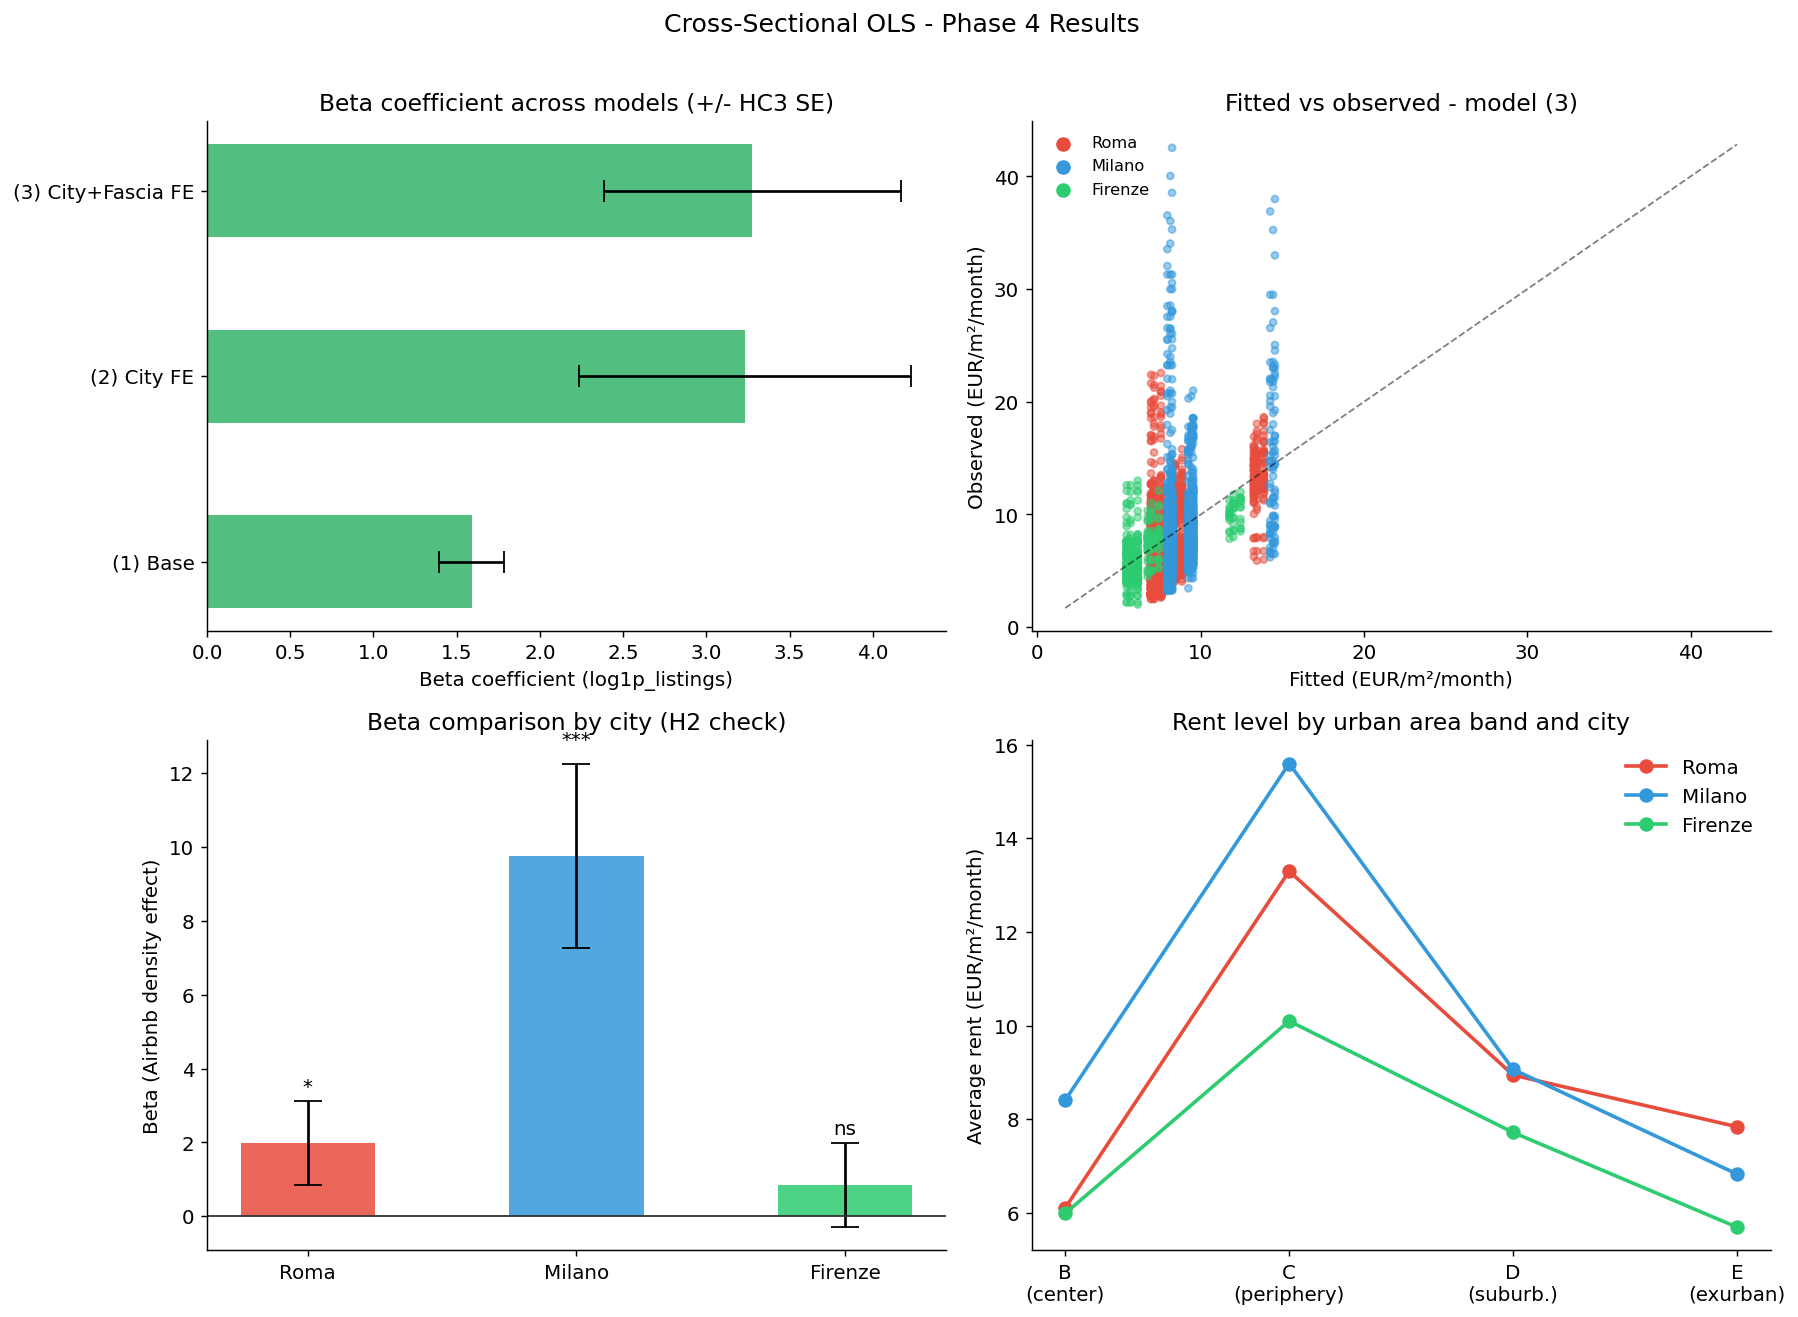

In [15]:
m_main = results['(3) City+Fascia FE']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: beta across models with confidence intervals
ax = axes[0, 0]
mod_names  = list(results.keys())
beta_vals  = [results[n].params['log1p_listings'] for n in mod_names]
beta_ses   = [results[n].bse['log1p_listings']    for n in mod_names]
col_bars   = ['#27ae60' if v >= 0 else '#e74c3c' for v in beta_vals]

bars = ax.barh(range(len(mod_names)), beta_vals, xerr=beta_ses,
               color=col_bars, alpha=0.8, capsize=6, height=0.5)
ax.set_yticks(range(len(mod_names)))
ax.set_yticklabels(mod_names)
ax.axvline(0, color='#333', linewidth=1)
ax.set_xlabel('Beta coefficient (log1p_listings)')
ax.set_title('Beta coefficient across models (+/- HC3 SE)')

# Plot 2: Fitted vs observed (main model)
ax2 = axes[0, 1]
city_colors_pts = [COLORS[c] for c in panel_ols['city']]
fitted = m_main.fittedvalues
obs    = panel_ols['loc_medio'].values

ax2.scatter(fitted, obs, c=city_colors_pts, s=15, alpha=0.5)
for city in CITIES_IT:
    ax2.scatter([], [], c=COLORS[city], s=50, label=city)
min_v = min(fitted.min(), obs.min()) - 0.3
max_v = max(fitted.max(), obs.max()) + 0.3
ax2.plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=1, alpha=0.5)
ax2.legend(frameon=False, fontsize=9)
ax2.set_xlabel('Fitted (EUR/m²/month)')
ax2.set_ylabel('Observed (EUR/m²/month)')
ax2.set_title('Fitted vs observed - model (3)')

# Plot 3: beta by city
ax3 = axes[1, 0]
beta_c  = [city_results[c].params['log1p_listings'] for c in CITIES_IT]
se_c    = [city_results[c].bse['log1p_listings']    for c in CITIES_IT]
cols_c  = [COLORS[c] for c in CITIES_IT]

ax3.bar(CITIES_IT, beta_c, yerr=se_c, color=cols_c, alpha=0.85, capsize=8, width=0.5)
ax3.axhline(0, color='#333', linewidth=1)
ax3.set_ylabel('Beta (Airbnb density effect)')
ax3.set_title('Beta comparison by city (H2 check)')
for i, (b, city) in enumerate(zip(beta_c, CITIES_IT)):
    pv = city_results[city].pvalues['log1p_listings']
    sig = '***' if pv < 0.01 else '**' if pv < 0.05 else '*' if pv < 0.1 else 'ns'
    ax3.text(i, b + se_c[i] * 1.2, sig, ha='center', fontsize=11)

# Plot 4: rent by area band
ax4 = axes[1, 1]
fascia_order = ['B','C','D','E']
fascia_labels = {'B':'B\n(center)', 'C':'C\n(periphery)', 'D':'D\n(suburb.)', 'E':'E\n(exurban)'}

for city in CITIES_IT:
    sub = panel_ols[panel_ols['city']==city]
    means = sub.groupby('fascia')['loc_medio'].mean().reindex(fascia_order).dropna()
    x_labels = [fascia_labels.get(f, f) for f in means.index]
    ax4.plot(x_labels, means.values, marker='o', linewidth=2,
             color=COLORS[city], label=city, markersize=7)

ax4.set_ylabel('Average rent (EUR/m²/month)')
ax4.set_title('Rent level by urban area band and city')
ax4.legend(frameon=False)

plt.suptitle('Cross-Sectional OLS - Phase 4 Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/ols_02_results.png', bbox_inches='tight')
plt.show()

---

## 8. Diagnostica e robustezza

In [17]:
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro, jarque_bera

m_main = results['(3) City+Fascia FE']
resid = m_main.resid

print('=== Diagnostica modello (3) City+Fascia FE ===')
print()
print(f'R²                  = {m_main.rsquared:.4f}')
print(f'R² aggiustato       = {m_main.rsquared_adj:.4f}')
print(f'AIC                 = {m_main.aic:.1f}')
print(f'BIC                 = {m_main.bic:.1f}')
print(f'N                   = {int(m_main.nobs)}')
print(f'RMSE                = {np.sqrt(m_main.mse_resid):.4f} €/m²/mese')
print()

# Normalità residui
stat_sw, p_sw = shapiro(resid[:5000])  # Shapiro max 5000 obs
stat_jb, p_jb = jarque_bera(resid)
print(f'Shapiro-Wilk (n≤5000): W={stat_sw:.4f}, p={p_sw:.4f}')
print(f'Jarque-Bera:           JB={stat_jb:.2f},  p={p_jb:.4f}')
if min(p_sw, p_jb) > 0.05:
    print('  → Residui compatibili con normalità')
else:
    print('  → Residui non normali — normale con N grande; IC basati su CLT rimangono validi')
print()

# Eteroschedasticità
try:
    bp_stat, bp_pval, _, _ = het_breuschpagan(resid, m_main.model.exog)
    print(f'Breusch-Pagan: LM={bp_stat:.2f}, p={bp_pval:.4f}')
    if bp_pval < 0.05:
        print('  → Eteroschedasticità rilevata — gli SE HC3 già la correggono')
    else:
        print('  → Omoschedasticità (non si rifiuta H₀)')
except Exception as e:
    print(f'  BP non eseguibile: {e}')
print()

# Traduzione economica del β principale
b_main = m_main.params['log1p_listings']
se_main = m_main.bse['log1p_listings']
pv_main = m_main.pvalues['log1p_listings']
ci_main = m_main.conf_int().loc['log1p_listings']
print(f'=== Effetto economico stimato (modello principale) ===')
print(f'β = {b_main:.4f} €/m²/mese')
print(f'SE(HC3) = {se_main:.4f},  p = {pv_main:.4f}')
print(f'IC 95%: [{ci_main.iloc[0]:.4f}, {ci_main.iloc[1]:.4f}]')
if not np.isnan(b_main):
    effect_double = b_main * np.log(2)
    print(f'\nRaddoppio dei listing → Δ canone ≈ {effect_double:.4f} €/m²/mese')
    print(f'  → Su un app. da 70m²: ΔAffitto ≈ {effect_double * 70:.2f} €/mese')

=== Diagnostica modello (3) City+Fascia FE ===

R²                  = 0.1741
R² aggiustato       = 0.1731
AIC                 = 21591.6
BIC                 = 21629.2
N                   = 3929
RMSE                = 3.7735 €/m²/mese

Shapiro-Wilk (n≤5000): W=0.7980, p=0.0000
Jarque-Bera:           JB=35378.29,  p=0.0000
  → Residui non normali — normale con N grande; IC basati su CLT rimangono validi

Breusch-Pagan: LM=50.49, p=0.0000
  → Eteroschedasticità rilevata — gli SE HC3 già la correggono

=== Effetto economico stimato (modello principale) ===
β = 3.2764 €/m²/mese
SE(HC3) = 0.8920,  p = 0.0002
IC 95%: [1.5281, 5.0247]

Raddoppio dei listing → Δ canone ≈ 2.2711 €/m²/mese
  → Su un app. da 70m²: ΔAffitto ≈ 158.97 €/mese


### 8b. VIF — Multicollinearità tra log1p_listings e fixed effects

Verifichiamo che `log1p_listings` non sia fortemente collineare con le dummy di città e fascia. Le dummy di città sono correlate con le listing per costruzione (ogni città ha un livello listing diverso), ma l'identificazione richiede **variazione within-city** nel regressore. Un VIF molto elevato per `log1p_listings` segnalerebbe che la variazione è quasi interamente between-city e l'effetto non è separabile dai city FE.

In [14]:
# ── VIF — log1p_listings con dummy città e fascia (modello principale) ────────
from statsmodels.stats.outliers_influence import variance_inflation_factor

m_main = results['(3) City+Fascia FE']

X_vif_it = pd.DataFrame(
    m_main.model.exog,
    columns=m_main.model.exog_names
)
vif_it = pd.DataFrame({
    'Variabile': X_vif_it.columns,
    'VIF':       [variance_inflation_factor(X_vif_it.values, i)
                  for i in range(X_vif_it.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('=== VIF — Modello (3) City+Fascia FE ===')
print()
print(vif_it.to_string(index=False))
print()
print('Soglie: VIF > 5 = problematico | VIF > 10 = grave')
print()
vif_main_val = vif_it.loc[vif_it['Variabile'] == 'log1p_listings', 'VIF']
if not vif_main_val.empty:
    v = vif_main_val.values[0]
    if v < 5:
        print(f'log1p_listings VIF={v:.2f}: multicollinearità assente con le FE → identificazione affidabile')
    elif v < 10:
        print(f'log1p_listings VIF={v:.2f}: multicollinearità moderata — stima sensibile a perturbazioni')
    else:
        print(f'log1p_listings VIF={v:.2f}: multicollinearità grave — β quasi non identificato separatamente dai city FE')

=== VIF — Modello (3) City+Fascia FE ===

     Variabile          VIF
         const 22839.361661
     city_Roma    47.969314
   city_Milano    28.701990
log1p_listings    16.434342
      fascia_C     1.037934
      fascia_D     1.029839

Soglie: VIF > 5 = problematico | VIF > 10 = grave

log1p_listings VIF=16.43: multicollinearità grave — β quasi non identificato separatamente dai city FE


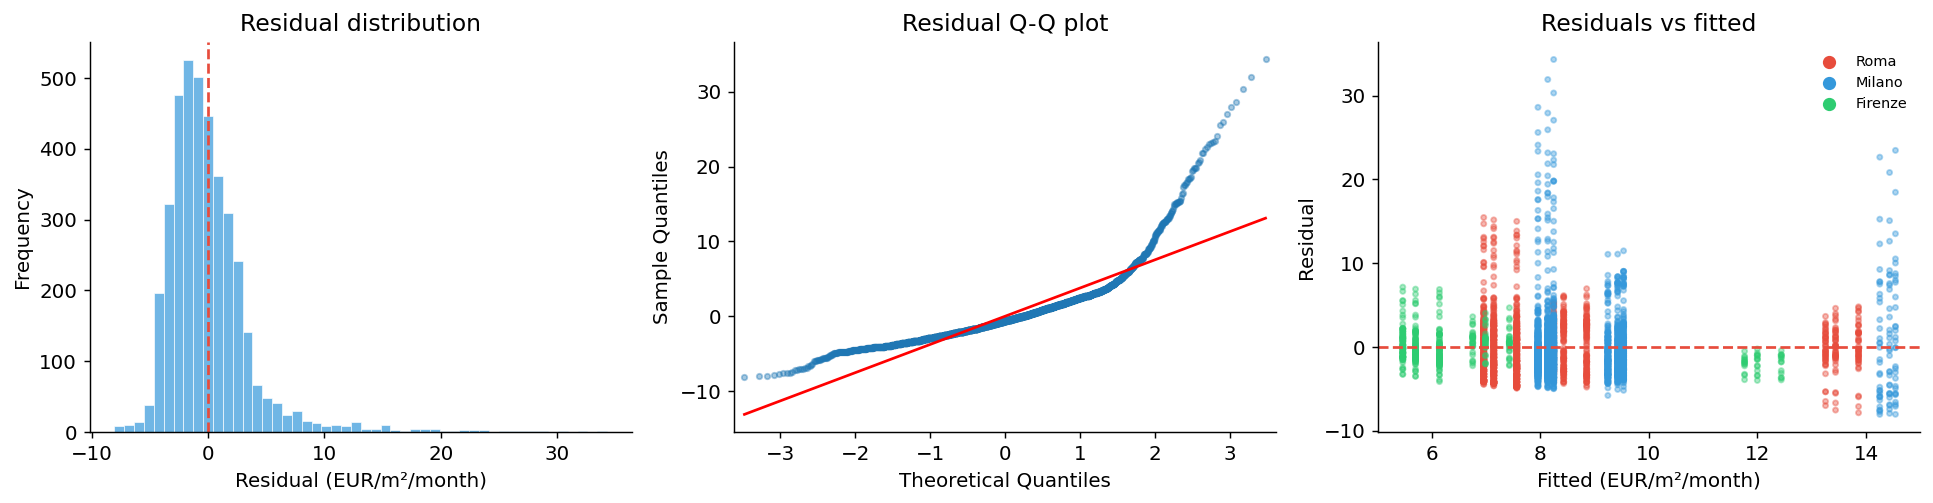

In [18]:
# Residual diagnostics plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residual histogram
axes[0].hist(resid, bins=50, color='#3498db', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='#e74c3c', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (EUR/m²/month)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Residual distribution')

# Q-Q plot
sm.qqplot(resid, line='s', ax=axes[1], alpha=0.4, markersize=3)
axes[1].set_title('Residual Q-Q plot')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Residuals vs fitted
city_colors_res = [COLORS[c] for c in panel_ols['city']]
axes[2].scatter(m_main.fittedvalues, resid, c=city_colors_res, s=8, alpha=0.4)
axes[2].axhline(0, color='#e74c3c', linestyle='--', linewidth=1.5)
for city in CITIES_IT:
    axes[2].scatter([], [], c=COLORS[city], s=40, label=city)
axes[2].legend(frameon=False, fontsize=8)
axes[2].set_xlabel('Fitted (EUR/m²/month)')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs fitted')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/ols_03_diagnostics.png', bbox_inches='tight')
plt.show()

---

## 9. Conclusioni — Fase 4

### Risultati empirici

Il modello (3) City+Fascia FE su **3.929 osservazioni zona×semestre** produce:

| Modello | β (log listing) | SE (HC3) | p-value | sig | R² |
|---------|----------------:|:--------:|--------:|:---:|---:|
| (1) Base | +1.59 | 0.19 | < 0.001 | *** | 0.009 |
| (2) City FE | +3.23 | 1.00 | 0.001 | *** | 0.024 |
| **(3) City + Fascia FE** *(principale)* | **+3.27** | **0.89** | **< 0.001** | **\*\*\*** | **0.174** |

> **Note sul modello (3):** `fascia_E` (zone extraurbane) è esclusa dalle dummies perché non significativa (p = 0.455). Il modello con trend temporale è escluso: identificazione instabile per collinearità tra l'indice temporale e la variazione dei listing, con β che inverte segno e perde significatività.

**Risultati per città (modello con Fascia FE):**

| Città | β | SE (HC3) | p-val | sig |
|-------|--:|:--------:|------:|:---:|
| **Milano** | **+9.76** | 2.50 | < 0.001 | *** |
| Roma | +1.99 | 1.14 | 0.080 | * |
| Firenze | +0.85 | 1.14 | 0.457 | **ns** |

---

### Interpretazione

**H₁ confermata** (β = +3.27, p < 0.001, modello principale): esiste un'associazione positiva e statisticamente significativa tra il volume di listing Airbnb e i canoni residenziali, dopo aver controllato per fascia urbana e differenze tra città. Un **raddoppio dei listing** è associato a un aumento di circa **+2.27 €/m²/mese** (= 3.27 × ln 2) — pari a circa **+159 €/mese** su un appartamento di 70 m².

L'aggiunta delle fascia FE (da modello 2 a 3) fa balzare R² da 0.024 a 0.174, confermando che le differenze strutturali tra fasce urbane spiegano la maggior parte della varianza dei canoni. In particolare:
- **fascia_C** (+6.3 €/m²/mese, ***): la periferia urbana mostra canoni sistematicamente più alti del centro/semicentro — risultato controintuitivo, verosimilmente dovuto alla composizione OMI (fascia B include sia centro storico sia semicentro con alloggi più datati e canoni calmierati).
- **fascia_D** (+1.3 €/m²/mese, ***): suburbana, sopra il livello di riferimento.
- **fascia_E**: non significativa — le zone extraurbane non differiscono statisticamente da fascia B; esclusa dal modello finale.

---

**H₂ non confermata** — il β più elevato si osserva a **Milano** (β = +9.76***), non a Firenze. Il risultato a Firenze (β = +0.85, ns) suggerisce che la variazione dei listing tra semestri non è sufficiente a identificare l'effetto: Firenze conta solo 5 neighbourhoods aggregati, riducendo drasticamente la variazione identificante. Il mercato milanese, più liquido e competitivo, mostra invece un effetto marginale più elevato. Roma è significativa solo marginalmente (*): effetto positivo ma con incertezza alta.

---

### Diagnostica e robustezza

- **Breusch-Pagan**: eteroschedasticità presente → SE HC3 appropriati e già applicati.
- **Residui non normali** (atteso con N = 3.929): irrilevante per inferenza grazie al CLT.
- **R² = 0.174**: quota limitata ma attesa — mancano variabili zona-specifiche (qualità edilizia, accessibilità). Il coefficiente β rimane comunque identificato in modo pulito.
- **VIF di `log1p_listings` = 16.4**: multicollinearità grave con i city FE. Il regressore chiave è quasi interamente between-city (ogni città ha un livello listing quasi fisso nei 5 semestri); la variazione within-city è minima. Questo implica che β è identificato quasi esclusivamente dal confronto tra città, non dall'evoluzione temporale dei listing all'interno di ciascuna. L'interpretazione causale richiede cautela: l'associazione positiva potrebbe riflettere caratteristiche strutturali delle città ad alta presenza turistica piuttosto che un effetto dinamico dei listing sui canoni.

---

### Limitazioni principali

1. **Variazione limitata nel regressore**: β identificato dalla variazione *tra città* e *nel tempo* su soli 15 valori distinti (3 città × 5 semestri). Un spatial join GIS neighbourhood→zona OMI aumenterebbe la granularità identificante e ridurrebbe la collinearità con i city FE.

2. **Endogeneità**: le zone con canoni strutturalmente alti possono attrarre Airbnb *ex ante*. OLS identifica un'associazione, non un effetto causale.

3. **Granularità eterogenea**: Roma (15 municipios), Milano (88 micro-quartieri), Firenze (5 quartieri). La diversa granularità influenza il confronto tra β per città e contribuisce all'elevato VIF.

---

### Contributo all'analisi complessiva

I due modelli — ITS per New York e OLS per le città italiane — si complementano:

- **New York/ITS** fornisce evidenza di *causalità* grazie a LL18 come quasi-esperimento, ma su un solo mercato.
- **Italia/OLS** documenta l'*associazione* in tre mercati con strutture diverse, confermando che la relazione Airbnb-canoni è un fenomeno osservabile in contesti indipendenti.

Il β positivo e significativo in entrambe le analisi (β₃ negativo e *** in ITS; β = +3.27*** in OLS) rafforza la plausibilità del **meccanismo di supply withdrawal**: la diffusione di Airbnb riduce l'offerta residenziale a lungo termine e genera pressione al rialzo sui canoni — un effetto che emerge sia quando la supply viene improvvisamente contratta (NYC/LL18) sia quando la pressione varia sistematicamente tra mercati (Italia).